# Analysis of Madden 24 Player Ratings  
### Unsupervised Learning: K-Means Clustering

---

## 1. Project Overview

This notebook explores the structure of NFL player data using ratings from the **Madden 24** video game.  
The primary objective is to perform a **clustering analysis** on the **principal components** of the data.  
By focusing purely on skill ratings, we aim to group players based on their statistical similarities in a reduced-dimensional space.

---

## 2. Dataset

The data is sourced from **Madden 24 Player Ratings**.

### Preprocessing
- We isolate skill ratings by removing data coloumns such as:
  - Team  
  - Position  
  - Name  
  - Jersey Number  
  - Salary-related information  
  - Height
  - Weight

### Feature Space
The analysis focuses exclusively on the **continuous rating variables** to derive clusters based on performance attributes.

---

## 3. Methodology

To analyze this dataset, we employ a two-step pipeline:

### **Dimensionality Reduction (PCA)**
We use **Principal Component Analysis** to compress the player attributes into **2 principal components**.  
This transformation allows us to perform clustering on a simplified 2D representation of player skill ratings.

### **Clustering (K-Means)**
We apply **K-Means clustering** directly to the PCA results.  
Two cluster configurations are tested:

- **\( k = 3 \)**: To establish a baseline grouping.  
- **\( k = 6 \)**: To observe how the algorithm further partitions the data.

---

## 4. Evaluation

We evaluate the quality of our clusters using:

- **Inertia**: Measures how compact the clusters are.  
- **Silhouette Score**: Measures how well-separated the clusters are.  
- **Visual Inspection**: Helps identify limitations of K-Means, especially how its assumption of spherical clusters interacts with the actual shape of the PCA-projected data.

---

Principal Component Vectors:
 [[-0.01327968 -0.08956466 -0.07857797  0.08931441 -0.09714026  0.01293765
  -0.19666788 -0.178206   -0.07812024 -0.00097056  0.0032636   0.07364608
   0.09386598  0.08192903 -0.25960376 -0.05762207 -0.22609426  0.00221829
  -0.02159216  0.00420147 -0.11191791 -0.1268471  -0.2673348  -0.14672511
  -0.25305358 -0.26936783  0.16058393  0.12496001  0.13086886  0.13661062
   0.13680118  0.11319683 -0.0749787  -0.05959486  0.12759353  0.09625655
   0.06954325  0.04590057  0.06512981 -0.0424536  -0.04545703 -0.23035162
  -0.22280293 -0.21308669 -0.22650002 -0.22101303  0.09315969 -0.06064982
  -0.18904925 -0.10280552 -0.08314505 -0.06863094 -0.06796201 -0.09145004]
 [-0.01889045 -0.06433002 -0.06448939  0.02188174 -0.06834123 -0.01250731
  -0.07094826 -0.01826755  0.06370794  0.0467808   0.03718854  0.09853324
   0.09125517 -0.26574809 -0.01575768 -0.05308049 -0.05764076 -0.00380515
  -0.01001429 -0.00176751  0.00335034 -0.07351335 -0.05396722 -0.01822468
  -0.07

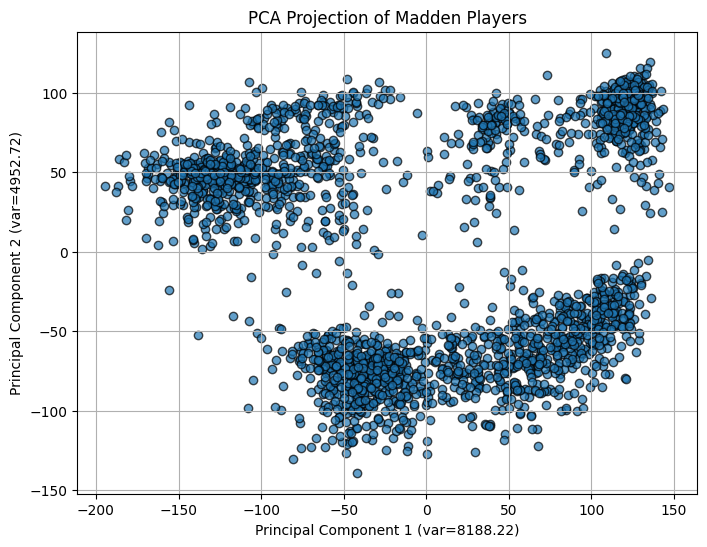

In [14]:
from matplotlib import pyplot as plt
import pandas as pd

from ml import compute_pca, kmeans_clustering

madden = pd.read_csv("madden.csv")
#drop noncontinuos coloumns and ones which arent ratings
drop_cols = [
    "Team","Position","Full Name","Jersey Number","Birthdate",
    "Running Style","Archetype","College"," Total Salary ",
    " Signing Bonus ","Player Handness","Height","Weight","Age","Years Pro"
]
madden_clean = madden.drop(columns=drop_cols)

X = madden_clean.to_numpy()
components, explained_variance, transformed_data = compute_pca(X, n_components=2)

# Create dataframe with 2 PCA columns

# Run PCA with 2 components
components, explained_variance, transformed_data = compute_pca(X, n_components=2)

# Two vectors:
# 1. The principal component vectors (shape: (2, n_features))
pc_vectors = components

# 2. The transformed data (projection onto the 2 components, shape: (n_samples, 2))
pc_projection = transformed_data

print("Principal Component Vectors:\n", pc_vectors)
print("Projected Data (2D):\n", pc_projection)


plt.figure(figsize=(8,6))
plt.scatter(transformed_data[:,0], transformed_data[:,1], alpha=0.7, edgecolors='k')

plt.xlabel(f'Principal Component 1 (var={explained_variance[0]:.2f})')
plt.ylabel(f'Principal Component 2 (var={explained_variance[1]:.2f})')
plt.title('PCA Projection of Madden Players')
plt.grid(True)
plt.show()




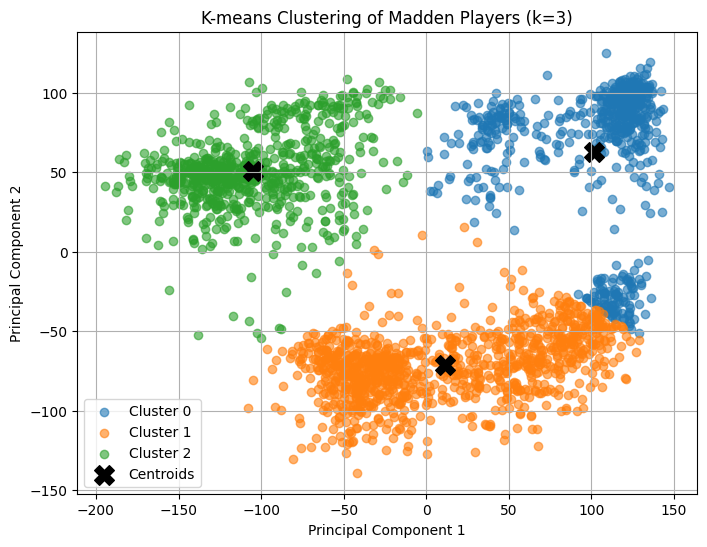

In [15]:
# Apply K-means with k=3
centroids, labels = kmeans_clustering(pc_projection, k=3, max_iter=100)
# Visualization
plt.figure(figsize=(8,6))
for cluster_id in range(3):
    cluster_points = pc_projection[labels == cluster_id]
    plt.scatter(cluster_points[:,0], cluster_points[:,1],
                label=f'Cluster {cluster_id}', alpha=0.6)

# Plot centroids
plt.scatter(centroids[:,0], centroids[:,1],
            c='black', marker='X', s=200, label='Centroids')

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('K-means Clustering of Madden Players (k=3)')
plt.legend()
plt.grid(True)
plt.show()


This result showcases both the power of K-means clustering and its downsides. Visually, it is clear that some points in Cluster 0 should actually be in Cluster 1. However, since K-means enforces circular clusters, we end up with these misclassifications. Despite this, the algorithm did identify the three approximate clusters.

In [16]:
from ml import compute_inertia
from ml import compute_silhouette_score

print(compute_inertia(pc_projection, centroids, labels))
print(compute_silhouette_score(pc_projection, labels))


7212265.082994344
0.5623536411657737


While the visual image is more of an indicator of its success, it did have a solid silhouette score of .56, though it is not ideal. 

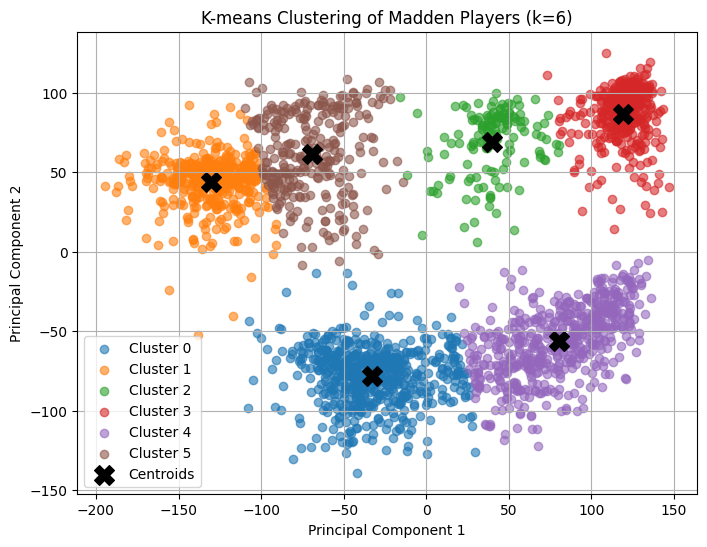

In [17]:
# Apply K-means with k=6
centroids, labels = kmeans_clustering(pc_projection, k=6, max_iter=100)
# Visualization
plt.figure(figsize=(8,6))
for cluster_id in range(6):
    cluster_points = pc_projection[labels == cluster_id]
    plt.scatter(cluster_points[:,0], cluster_points[:,1],
                label=f'Cluster {cluster_id}', alpha=0.6)

# Plot centroids
plt.scatter(centroids[:,0], centroids[:,1],
            c='black', marker='X', s=200, label='Centroids')

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('K-means Clustering of Madden Players (k=6)')
plt.legend()
plt.grid(True)
plt.show()


In [18]:
print(compute_silhouette_score(pc_projection, labels))
print(compute_inertia(pc_projection, centroids, labels))

0.5707125149804352
2195570.846300882


Notice that applying $k=6$ splits what appears to be single clusters into multiple. Increasing $k$ reduces the intertia, but it does not necesarily make the clustering better, and this can be seen visually. It does however keep a prety similar silhouette score. This shows how picking the correct $k$ is important in k means clustering. Also, yet again, due to the fact that the clusters are circular, we end up with points which appear to be in the wrong cluster. 